# **🏠 Feature Engineering**

---

# 1. Feature Engineering Summary

## Objectives

- Investigate the dataset for potential feature engineering opportunities for the regression model.
  - Assess numerical features for transformations where appropriate.
  - Prepare categorical and numerical variables for machine learning.

## Inputs

- `outputs/datasets/cleaned/house_prices_cleaned.csv`

## Outputs

- Feature engineering analysis and conclusions to inform the machine learning pipeline.

---

## ⚙️ 2. Set Up the Notebook

### Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/milestone-project5-heritage-housing-issues/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chdir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/milestone-project5-heritage-housing-issues'

---

## 📥 3. Load Data



In [4]:
import pandas as pd

df = pd.read_csv("outputs/datasets/cleaned/house_prices_cleaned.csv")
df.head()

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,548,RFn,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,460,RFn,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,608,RFn,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500
3,961,0.0,3.0,No,216,ALQ,540,642,Unf,1998.0,...,9550,60.0,0.0,35,5,7,756,1915,1970,140000
4,1145,0.0,4.0,Av,655,GLQ,490,836,RFn,2000.0,...,14260,84.0,350.0,84,5,8,1145,2000,2000,250000


---

# 4. Train and Test Set

Before investigating and applying feature engineering techniques, the dataset is split into training and test sets.

In [5]:
from sklearn.model_selection import train_test_split

TrainSet, TestSet, _, __ = train_test_split(
    df,
    df['SalePrice'],
    test_size=0.2,
    random_state=0
)

print(f"TrainSet shape: {TrainSet.shape} \nTestSet shape: {TestSet.shape}")

TrainSet shape: (1168, 22) 
TestSet shape: (292, 22)


---

## 5. Training Set Profile

A profiling report is generated for the training set to examine feature distributions and identify potential feature engineering opportunities.

In [6]:
from ydata_profiling import ProfileReport

pandas_report = ProfileReport(df=TrainSet, minimal=True)
pandas_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 6. Initial Feature Engineering Assessment

Before applying feature engineering techniques, the distributions and characteristics of each variable were reviewed based on the ydata profiling report.

The purpose of this assessment is to identify features that may benefit from transformation or encoding while avoiding unnecessary transformations. Particular attention was given to skewness, meaningful zero values, categorical structure, and ordinal variables.

| Type | Variable | Observation | Investigation |
|---|---|---|---|
| Numerical | `1stFlrSF` | Moderately right-skewed with some high values; no zeros | Investigate numerical transformation |
| Numerical | `2ndFlrSF` | 58.7% zeros representing no second-floor area; non-zero values have a broad distribution | Investigate; likely retain due to meaningful zeros |
| Numerical | `BedroomAbvGr` | Discrete count, low skew, mainly 2–4 bedrooms. Only four zero values | Retain without transformation |
| Categorical | `BsmtExposure` | 5 categorical levels describing basement exposure, including no basement | Investigate categorical encoding |
| Numerical | `BsmtFinSF1` | 32.6% meaningful zeros; moderately right-skewed; non-zero values extend to 2,260 sq ft | Investigate; likely retain due to meaningful zeros |
| Categorical | `BsmtFinType1` | 8 categorical levels describing basement finish type/quality; no missing values | Investigate categorical encoding |
| Numerical | `BsmtUnfSF` | 7.9% meaningful zeros; moderately right-skewed; values extend to 2,153 sq ft | Investigate; likely retain due to meaningful zeros |
| Numerical | `GarageArea` | 5% meaningful zeros representing no garage; very low skew; distribution otherwise reasonably balanced | Retain without transformation |
| Categorical | `GarageFinish` | 5 categorical levels describing garage finish/absence; no missing values | Investigate categorical encoding |
| Numerical | `GarageYrBlt` | 5% meaningful zeros representing no garage; remaining values are construction years; zeros cause strong negative skew | Retain without transformation |
| Numerical | `GrLivArea` | Right-skewed, no zeros, with some unusually large living areas | Investigate numerical transformation |
| Categorical | `KitchenQual` | 4 categories with a clear natural quality order (Fa < TA < Gd < Ex); no missing values | Investigate ordinal encoding |
| Numerical | `LotArea` | Extremely right-skewed, with very large upper values; no zeros or negative values | Investigate numerical transformation |
| Numerical | `LotFrontage` | Strongly right-skewed, with high-value observations; no zeros or negative values | Investigate numerical transformation |
| Numerical | `MasVnrArea` | Strongly right-skewed, but 60.3% of observations are meaningful zeros representing no masonry veneer area | Investigate; likely retain due to meaningful zeros |
| Numerical | `OpenPorchSF` | Strongly right-skewed, but 44.6% are meaningful zeros representing no open porch area | Investigate; likely retain due to meaningful zeros |
| Numerical | `OverallCond` | Ordinal rating from 1–9; values already represent an ordered condition scale | Retain without transformation |
| Numerical | `OverallQual` | Ordinal rating from 1–10; already represented as a meaningful ordered numerical scale | Retain without transformation |
| Numerical | `TotalBsmtSF` | Moderately right-skewed; 2.4% meaningful zeros representing no basement; a few large values | Investigate; likely retain due to meaningful zeros |
| Numerical | `YearBuilt` | Left-skewed; values range from 1872–2010; skew reflects more newer than older properties | Retain without transformation |
| Numerical | `YearRemodAdd` | Uneven/left-skewed distribution; values range from 1950–2010 | Retain without transformation |
| Target | `SalePrice` | Right-skewed target with a long upper tail | Investigate target transformation separately |



## 7. Feature Engineering



In [7]:
import scipy.stats as stats
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
import warnings
from feature_engine import transformation as vt
from feature_engine.outliers import Winsorizer
from feature_engine.encoding import OrdinalEncoder
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')


def FeatureEngineeringAnalysis(df, analysis_type=None):
    """
    - used for quick feature engineering on numerical and categorical variables
    to decide which transformation can better transform the distribution shape
    - Once transformed, use a reporting tool, like ydata-profiling, to evaluate distributions
    """
    check_missing_values(df)
    allowed_types = ['numerical', 'ordinal_encoder', 'outlier_winsorizer']
    check_user_entry_on_analysis_type(analysis_type, allowed_types)
    list_column_transformers = define_list_column_transformers(analysis_type)

    # Loop in each variable and engineer the data according to the analysis type
    df_feat_eng = pd.DataFrame([])
    for column in df.columns:
        # create additional columns (column_method) to apply the methods
        df_feat_eng = pd.concat([df_feat_eng, df[column]], axis=1)
        for method in list_column_transformers:
            df_feat_eng[f"{column}_{method}"] = df[column]

        # Apply transformers in respective column_transformers
        df_feat_eng, list_applied_transformers = apply_transformers(
            analysis_type, df_feat_eng, column)

        # For each variable, assess how the transformations perform
        transformer_evaluation(
            column, list_applied_transformers, analysis_type, df_feat_eng)

    return df_feat_eng


def check_user_entry_on_analysis_type(analysis_type, allowed_types):
    """ Check analysis type """
    if analysis_type is None:
        raise SystemExit(
            f"You should pass analysis_type parameter as one of the following options: {allowed_types}")
    if analysis_type not in allowed_types:
        raise SystemExit(
            f"analysis_type argument should be one of these options: {allowed_types}")


def check_missing_values(df):
    if df.isna().sum().sum() != 0:
        raise SystemExit(
            f"There is a missing value in your dataset. Please handle that before getting into feature engineering.")


def define_list_column_transformers(analysis_type):
    """ Set suffix columns according to analysis_type"""
    if analysis_type == 'numerical':
        list_column_transformers = [
            "log_e", "log_10", "reciprocal", "power", "box_cox", "yeo_johnson"]

    elif analysis_type == 'ordinal_encoder':
        list_column_transformers = ["ordinal_encoder"]

    elif analysis_type == 'outlier_winsorizer':
        list_column_transformers = ['iqr']

    return list_column_transformers


def apply_transformers(analysis_type, df_feat_eng, column):
    for col in df_feat_eng.select_dtypes(include='category').columns:
        df_feat_eng[col] = df_feat_eng[col].astype('object')

    if analysis_type == 'numerical':
        df_feat_eng, list_applied_transformers = FeatEngineering_Numerical(
            df_feat_eng, column)

    elif analysis_type == 'outlier_winsorizer':
        df_feat_eng, list_applied_transformers = FeatEngineering_OutlierWinsorizer(
            df_feat_eng, column)

    elif analysis_type == 'ordinal_encoder':
        df_feat_eng, list_applied_transformers = FeatEngineering_CategoricalEncoder(
            df_feat_eng, column)

    return df_feat_eng, list_applied_transformers


def transformer_evaluation(column, list_applied_transformers, analysis_type, df_feat_eng):
    # For each variable, assess how the transformations perform
    print(f"* Variable Analyzed: {column}")
    print(f"* Applied transformation: {list_applied_transformers} \n")
    for col in [column] + list_applied_transformers:

        if analysis_type != 'ordinal_encoder':
            DiagnosticPlots_Numerical(df_feat_eng, col)

        else:
            if col == column:
                DiagnosticPlots_Categories(df_feat_eng, col)
            else:
                DiagnosticPlots_Numerical(df_feat_eng, col)

        print("\n")


def DiagnosticPlots_Categories(df_feat_eng, col):
    plt.figure(figsize=(4, 3))
    sns.countplot(data=df_feat_eng, x=col, palette=[
                  '#432371'], order=df_feat_eng[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.suptitle(f"{col}", fontsize=30, y=1.05)
    plt.show()
    print("\n")


def DiagnosticPlots_Numerical(df, variable):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    sns.histplot(data=df, x=variable, kde=True, element="step", ax=axes[0])
    stats.probplot(df[variable], dist="norm", plot=axes[1])
    sns.boxplot(x=df[variable], ax=axes[2])

    axes[0].set_title('Histogram')
    axes[1].set_title('QQ Plot')
    axes[2].set_title('Boxplot')
    fig.suptitle(f"{variable}", fontsize=30, y=1.05)
    plt.tight_layout()
    plt.show()


def FeatEngineering_CategoricalEncoder(df_feat_eng, column):
    list_methods_worked = []
    try:
        encoder = OrdinalEncoder(encoding_method='arbitrary', variables=[
                                 f"{column}_ordinal_encoder"])
        df_feat_eng = encoder.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_ordinal_encoder")

    except Exception:
        df_feat_eng.drop([f"{column}_ordinal_encoder"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_OutlierWinsorizer(df_feat_eng, column):
    list_methods_worked = []

    # Winsorizer iqr
    try:
        disc = Winsorizer(
            capping_method='iqr', tail='both', fold=1.5, variables=[f"{column}_iqr"])
        df_feat_eng = disc.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_iqr")
    except Exception:
        df_feat_eng.drop([f"{column}_iqr"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_Numerical(df_feat_eng, column):
    list_methods_worked = []

    # LogTransformer base e
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_e"])
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_e")
    except Exception:
        df_feat_eng.drop([f"{column}_log_e"], axis=1, inplace=True)

    # LogTransformer base 10
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_10"], base='10')
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_10")
    except Exception:
        df_feat_eng.drop([f"{column}_log_10"], axis=1, inplace=True)

    # ReciprocalTransformer
    try:
        rt = vt.ReciprocalTransformer(variables=[f"{column}_reciprocal"])
        df_feat_eng = rt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_reciprocal")
    except Exception:
        df_feat_eng.drop([f"{column}_reciprocal"], axis=1, inplace=True)

    # PowerTransformer
    try:
        pt = vt.PowerTransformer(variables=[f"{column}_power"])
        df_feat_eng = pt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_power")
    except Exception:
        df_feat_eng.drop([f"{column}_power"], axis=1, inplace=True)

    # BoxCoxTransformer
    try:
        bct = vt.BoxCoxTransformer(variables=[f"{column}_box_cox"])
        df_feat_eng = bct.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_box_cox")
    except Exception:
        df_feat_eng.drop([f"{column}_box_cox"], axis=1, inplace=True)

    # YeoJohnsonTransformer
    try:
        yjt = vt.YeoJohnsonTransformer(variables=[f"{column}_yeo_johnson"])
        df_feat_eng = yjt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_yeo_johnson")
    except Exception:
        df_feat_eng.drop([f"{column}_yeo_johnson"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked

## 7.1 Categorical Encoding Investigation

Machine learning models require categorical variables to be represented numerically.

The categorical variables identified during the initial feature engineering assessment will therefore be investigated for encoding. Ordinal and one-hot encoding will be considered depending on the characteristics of each variable.

### Categorical Variable Assessment

The categorical variables were reviewed before encoding to determine whether their categories have a meaningful natural order.

| Variable | Assessment | Proposed Encoding |
|---|---|---|
| `BsmtExposure` | Basement exposure has an ordered progression (`No`, `Mn`, `Av`, `Gd`), while `No Basement` represents the absence of a basement. | Ordinal encoding |
| `BsmtFinType1` | Basement finish categories describe different types and quality levels but do not form a clear linear order. `No Basement` and `Missing` also have distinct meanings. | One-hot encoding avoids imposing an artificial numerical order. |
| `GarageFinish` | Garage finish has a natural progression (`Unf`, `RFn`, `Fin`). `No Garage` represents structural absence and `Missing` represents unknown information. | Ordinal encoding |
| `KitchenQual` | Kitchen quality has a clear natural order (`Fa`, `TA`, `Gd`, `Ex`). | Ordinal encoding |

### Ordinal Encoding

**Step 1 — Select the categorical variables for Ordinal Encoding**

In [8]:
ordinal_variables = [
    'BsmtExposure',
    'GarageFinish',
    'KitchenQual'
]

**Step 2 — Create a Separate DataFrame**

In [9]:
df_ordinal = TrainSet[ordinal_variables].copy()
df_ordinal.head()

,BsmtExposure,GarageFinish,KitchenQual
618,Av,Unf,Gd
870,No,Missing,TA
92,No,Unf,TA
817,No,RFn,Gd
302,No,RFn,Gd


**Step 3: Create engineered variables(s) by applying the transformation(s), assess engineered variables distribution and select the most suitable method for each variable.**

* Variable Analyzed: BsmtExposure
* Applied transformation: ['BsmtExposure_ordinal_encoder'] 



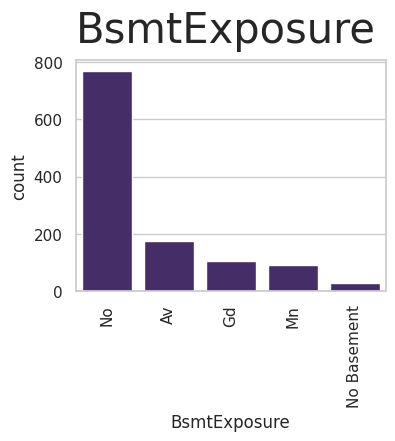

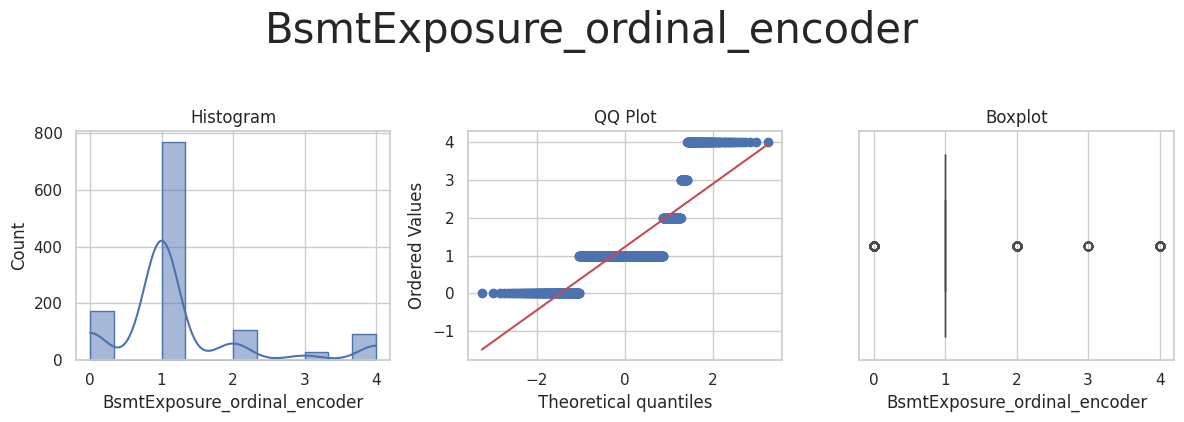



* Variable Analyzed: GarageFinish
* Applied transformation: ['GarageFinish_ordinal_encoder'] 



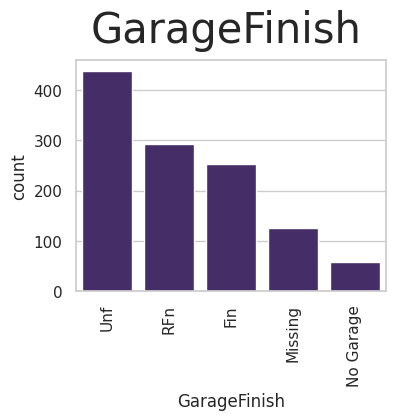

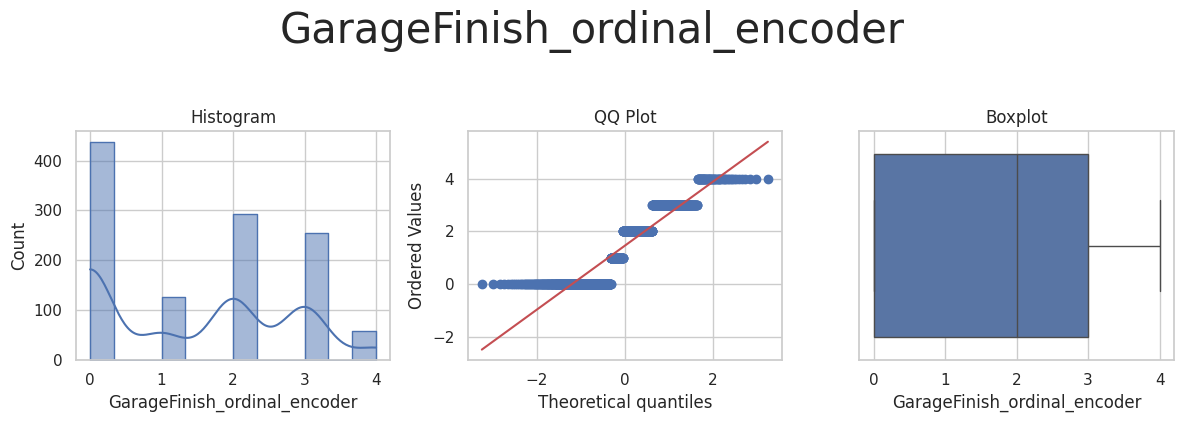



* Variable Analyzed: KitchenQual
* Applied transformation: ['KitchenQual_ordinal_encoder'] 



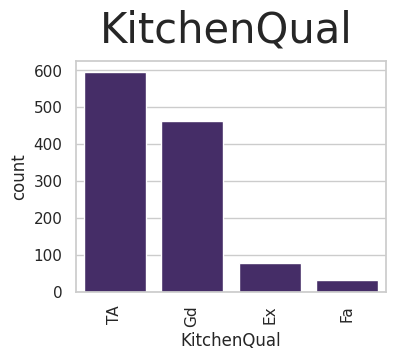

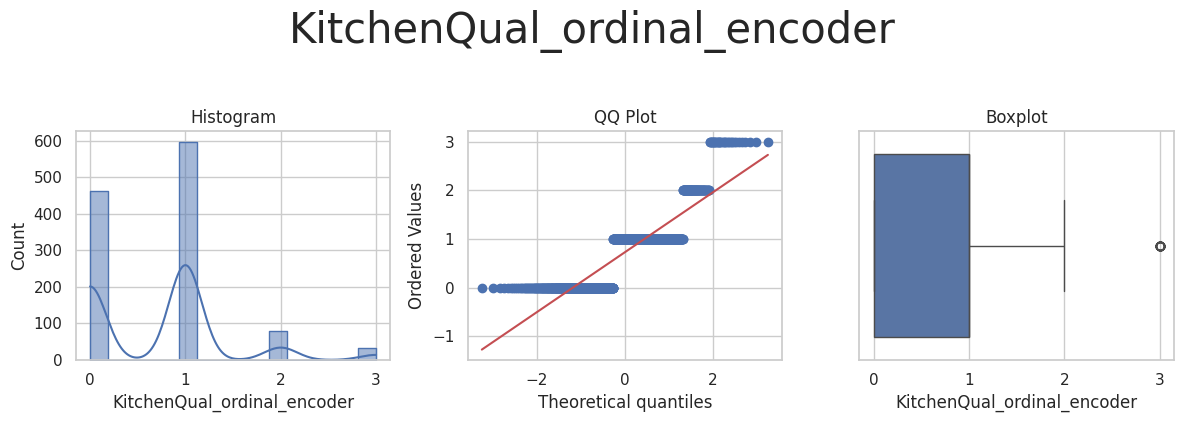

In [10]:
df_ordinal = FeatureEngineeringAnalysis(
    df=df_ordinal,
    analysis_type='ordinal_encoder'
)

**Step 4 — Apply the selected ordinal encoding to the training and test sets**

The ordinal categories are assigned numerical values.

In [11]:
encoder = OrdinalEncoder(
    encoding_method='arbitrary',
    variables=ordinal_variables
)

encoder.fit(TrainSet)

TrainSet = encoder.transform(TrainSet)
TestSet = encoder.transform(TestSet)

In [12]:
TrainSet[ordinal_variables].head()

,BsmtExposure,GarageFinish,KitchenQual
618,0,0,0
870,1,1,1
92,1,0,1
817,1,2,0
302,1,2,0


##### Ordinal Encoding Conclusion

The selected categorical variables were successfully converted to numerical values using arbitrary ordinal encoding. The encoder was fitted on the training set and then applied consistently to the test set.

### One-Hot Encoding

**Step 1 — Select the categorical variable for One-Hot Encoding**

`BsmtFinType1` was selected for one-hot encoding because its categories do not represent a clear linear order.

In [13]:
one_hot_variables = ['BsmtFinType1']

**Step 2 — Create a Separate DataFrame**

A separate DataFrame is created from the training set containing the selected variable for investigation.

In [14]:
df_one_hot = TrainSet[one_hot_variables].copy()
df_one_hot.head()

,BsmtFinType1
618,Missing
870,Unf
92,ALQ
817,GLQ
302,Unf


**Step 3 — Investigate the categories**

The categories and their frequencies are reviewed before applying one-hot encoding.

In [15]:
df_one_hot['BsmtFinType1'].value_counts()

BsmtFinType1
Unf            326
GLQ            303
ALQ            159
BLQ            114
Rec            100
Missing         86
LwQ             52
No Basement     28
Name: count, dtype: int64

**Step 4 — Apply One-Hot Encoding to the training and test sets**

The encoder is fitted on the training set and then applied consistently to both the training and test sets. Each category of `BsmtFinType1` is represented by a separate binary variable.

In [16]:
from feature_engine.encoding import OneHotEncoder

encoder_ohe = OneHotEncoder(
    variables=one_hot_variables,
    drop_last=False
)

encoder_ohe.fit(TrainSet)

TrainSet = encoder_ohe.transform(TrainSet)
TestSet = encoder_ohe.transform(TestSet)

In [17]:
TrainSet.filter(like='BsmtFinType1').head()

,BsmtFinType1_Missing,BsmtFinType1_Unf,BsmtFinType1_ALQ,BsmtFinType1_GLQ,BsmtFinType1_Rec,BsmtFinType1_No Basement,BsmtFinType1_LwQ,BsmtFinType1_BLQ
618,1,0,0,0,0,0,0,0
870,0,1,0,0,0,0,0,0
92,0,0,1,0,0,0,0,0
817,0,0,0,1,0,0,0,0
302,0,1,0,0,0,0,0,0


##### One-Hot Encoding Conclusion

`BsmtFinType1` was successfully converted into binary variables using one-hot encoding. The encoder was fitted on the training set and then applied consistently to the test set.

## 7.2 Numerical Transformation Investigation

Based on the initial feature engineering assessment, the numerical variables are grouped as follows:

| Decision | Variables |
|---|---|
| Investigate transformation | `1stFlrSF`, `GrLivArea`, `LotArea`, `LotFrontage` |
| Further investigation due to meaningful zeros | `2ndFlrSF`, `BsmtFinSF1`, `BsmtUnfSF`, `MasVnrArea`, `OpenPorchSF`, `TotalBsmtSF` |
| Retain without transformation | `BedroomAbvGr`, `GarageArea`, `GarageYrBlt`, `OverallCond`, `OverallQual`, `YearBuilt`, `YearRemodAdd` |

The first two groups will be assessed using numerical transformations before a final decision is made. `SalePrice` will be investigated separately as the target variable.


In [18]:
var_to_numerically_transform = [
    '1stFlrSF',
    '2ndFlrSF',
    'BsmtFinSF1',
    'BsmtUnfSF',
    'GrLivArea',
    'LotArea',
    'LotFrontage',
    'MasVnrArea',
    'OpenPorchSF',
    'TotalBsmtSF'
]

In [19]:
df_engineering = TrainSet[var_to_numerically_transform].copy()
df_engineering.head(3)

,1stFlrSF,2ndFlrSF,BsmtFinSF1,BsmtUnfSF,GrLivArea,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,TotalBsmtSF
618,1828,0.0,48,1774,1828,11694,90.0,452.0,108,1822
870,894,0.0,0,894,894,6600,60.0,0.0,0,894
92,964,0.0,713,163,964,13360,80.0,0.0,0,876


### Numerical Transformation Reference

The following transformations were investigated to understand whether they improve the distribution of numerical variables.

| Transformation | What it does | Typical use |
|---|---|---|
| **Natural Log (`log_e`)** | Replaces \(x\) with \(\ln(x)\), compressing large values more than small values. | Useful for reducing **right skew** and the influence of very large values. Requires positive values. |
| **Log Base 10 (`log_10`)** | Replaces \(x\) with \(\log_{10}(x)\). It has the same distributional shape as natural log but uses a different scale. | Same purpose as natural log; useful for **right-skewed positive data**. |
| **Reciprocal** | Replaces \(x\) with \(1/x\). Large values become small and small values become large. | Can reduce some forms of strong right skew, but reverses the scale and can exaggerate small values. Requires non-zero values. |
| **Power** | Applies a power transformation to change the relative spread of values. | Can reduce skew and compress large values while retaining meaningful zeros, depending on the power used. |
| **Box-Cox** | Searches for a suitable power transformation using a parameter called lambda (\(\lambda\)). | Useful for making **positive, skewed data** more symmetric. Requires strictly positive values. |
| **Yeo-Johnson** | Similar to Box-Cox but can also accommodate **zero and negative values**. | Useful for reducing skew when a variable contains zeros or negative values. |

In [20]:
%%capture

df_engineering = FeatureEngineeringAnalysis(
    df=df_engineering,
    analysis_type='numerical'
)

| Variable      | Key conclusion                                                                             | Selected transformation |
| ------------- | ------------------------------------------------------------------------------------------ | ----------------------- |
| `1stFlrSF`    | Log substantially improves symmetry and QQ alignment.                                      | **Natural log**         |
| `2ndFlrSF`    | Distribution is driven by meaningful zeros; transformation adds little benefit.            | **None**                |
| `BsmtFinSF1`  | Meaningful zeros remain dominant despite reduced non-zero skew.                            | **None**                |
| `BsmtUnfSF`   | Power reduces skew and improves the non-zero distribution.                                 | **Power**               |
| `GrLivArea`   | Log substantially reduces skew with strong QQ alignment.                                   | **Natural log**         |
| `LotArea`     | Log substantially reduces extreme right skew, although tail deviations remain.             | **Natural log**         |
| `LotFrontage` | Log gives the clearest reduction in right skew.                                            | **Natural log**         |
| `MasVnrArea`  | Distribution is dominated by meaningful zeros; transformation adds little benefit.         | **None**                |
| `OpenPorchSF` | Meaningful zeros strongly influence the distribution; transformation adds limited benefit. | **None**                |
| `TotalBsmtSF` | Power reduces skew and gives the strongest QQ alignment.                                   | **Power**               |


In [21]:
from sklearn.pipeline import Pipeline
from feature_engine import transformation as vt

pipeline = Pipeline([
    ("LogTransformer", vt.LogTransformer(
        variables=[
            '1stFlrSF',
            'GrLivArea',
            'LotArea',
            'LotFrontage'
        ]
    )),

    ("PowerTransformer", vt.PowerTransformer(
        variables=[
            'BsmtUnfSF',
            'TotalBsmtSF'
        ]
    )),
])

TrainSet = pipeline.fit_transform(TrainSet)
TestSet = pipeline.transform(TestSet)

print("Numerical transformation done!")

Numerical transformation done!


In [22]:
TrainSet[
    ['1stFlrSF', 'GrLivArea', 'LotArea', 'LotFrontage',
     'BsmtUnfSF', 'TotalBsmtSF']
].head()

,1stFlrSF,GrLivArea,LotArea,LotFrontage,BsmtUnfSF,TotalBsmtSF
618,7.510978,7.510978,9.366831,4.499810,42.118879,42.684892
870,6.795706,6.795706,8.794825,4.094345,29.899833,29.899833
92,6.871091,6.871091,9.500020,4.382027,12.767145,29.597297
817,7.431892,7.431892,9.492884,4.234107,18.708287,39.597980
302,7.340187,7.340187,9.525443,4.770685,39.255573,39.255573


#### Numerical Transformation Result

The selected numerical transformations were applied using a pipeline fitted on the training set and subsequently applied to the test set.

- **Natural log:** `1stFlrSF`, `GrLivArea`, `LotArea`, `LotFrontage`
- **Power:** `BsmtUnfSF`, `TotalBsmtSF`
- **No transformation:** `2ndFlrSF`, `BsmtFinSF1`, `MasVnrArea`, `OpenPorchSF`

The transformed values were reviewed to confirm that the pipeline was applied successfully.